<a href="https://colab.research.google.com/github/gevargas/furiatecnotravesti/blob/main/furIA_vocabulario_notebook_corpus_ecuador_rdf_property_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Corpus TXT → conceptos → RDF/OWL + grafo de propiedades

Este notebook implementa un flujo reproducible para:

1. **Leer varios archivos `.txt`** desde:
   - una carpeta, o
   - un archivo manifiesto (`.txt` o `.csv`) que enumera los documentos.
2. **Segmentar el corpus en frases** y conservar la procedencia de cada frase.
3. **Normalizar y lematizar español**, con una capa configurable para variantes y vocabulario de **Ecuador**.
4. **Explorar y filtrar conceptos interactivamente** mediante `ipywidgets`.
5. Construir un **grafo RDF/OWL** con `rdflib` y exportarlo como **Turtle (`.ttl`)**, que puede abrirse directamente en **Protégé**.
6. Construir un **grafo de propiedades** en el que dos conceptos se relacionan cuando aparecen en la **misma frase**.
7. Exportar el grafo de propiedades como **GraphML**, **GEXF** y tablas CSV de nodos/aristas.

> Nota lingüística: spaCy ofrece modelos generales de español, no un modelo morfológico exclusivo para el español ecuatoriano. Por ello el notebook usa un modelo de español y añade una **capa de normalización/lematización ecuatoriana configurable**, útil para regionalismos, variantes ortográficas, formas coloquiales y vocabulario del dominio.


In [2]:
# Si es la primera ejecución, instala dependencias.
# En Jupyter/Colab puedes descomentar y ejecutar:
#
%pip install -U spacy pandas networkx rdflib ipywidgets matplotlib tqdm
!python -m spacy download es_core_news_md
#
# Si es_core_news_md resulta pesado, puedes usar:
# !python -m spacy download es_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 17.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:

from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
import csv
import json
import re
import unicodedata

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from rdflib import Graph, Namespace, RDF, RDFS, OWL, XSD, Literal, URIRef
from rdflib.namespace import SKOS, DCTERMS

import spacy
from spacy.lang.es.stop_words import STOP_WORDS

from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets



## 1. Configuración del corpus

Hay dos modos:

### A. Carpeta
Define `INPUT_MODE = "folder"` y `CORPUS_FOLDER` con la carpeta que contiene los `.txt`.

### B. Manifiesto
Define `INPUT_MODE = "manifest"` y `MANIFEST_FILE`:
- `.txt`: una ruta de archivo por línea.
- `.csv`: debe tener una columna `path`.

Las rutas relativas del manifiesto se interpretan con respecto a la carpeta del propio manifiesto.


In [4]:

# ---------- CONFIGURACIÓN ----------
INPUT_MODE = "folder"   # "folder" o "manifest"

CORPUS_FOLDER = Path("/content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data")
MANIFEST_FILE = Path("./corpus_files.txt")

ENCODING = "utf-8"
RECURSIVE = True

OUTPUT_DIR = Path("/content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modelo spaCy
SPACY_MODEL = "es_core_news_md"   # cambiar a es_core_news_sm si fuera necesario


In [5]:

def read_manifest(path: Path):
    path = Path(path)
    base = path.parent
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        if "path" not in df.columns:
            raise ValueError("El CSV manifiesto debe contener una columna llamada 'path'.")
        items = df["path"].dropna().astype(str).tolist()
    else:
        items = [
            line.strip()
            for line in path.read_text(encoding=ENCODING).splitlines()
            if line.strip() and not line.lstrip().startswith("#")
        ]

    files = []
    for item in items:
        p = Path(item)
        if not p.is_absolute():
            p = base / p
        files.append(p.resolve())
    return files


def discover_txt_files():
    if INPUT_MODE == "folder":
        folder = Path(CORPUS_FOLDER)
        pattern = "**/*.txt" if RECURSIVE else "*.txt"
        files = sorted(folder.glob(pattern))
    elif INPUT_MODE == "manifest":
        files = read_manifest(MANIFEST_FILE)
    else:
        raise ValueError("INPUT_MODE debe ser 'folder' o 'manifest'.")

    files = [p for p in files if p.exists() and p.is_file() and p.suffix.lower() == ".txt"]
    if not files:
        raise FileNotFoundError("No se encontraron archivos .txt con la configuración actual.")
    return files


txt_files = discover_txt_files()
print(f"Archivos encontrados: {len(txt_files)}")
for p in txt_files[:10]:
    print(" -", p)
if len(txt_files) > 10:
    print(" ...")


Archivos encontrados: 16
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/E45A 2.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/E45A 3.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/E45A 4.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/E45A 5.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/E45A 6.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/E45A.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/furIA Machala 1.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/furIA Machala 2.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/furIA Machala 3.txt
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/furIA Machala 4.txt
 ...



## 2. Modelo de español + adaptación al español de Ecuador

La lematización base se realiza con spaCy. Encima se aplica un diccionario editable `ECUADOR_LEMMA_OVERRIDES`.

Puedes ampliarlo con:
- regionalismos ecuatorianos;
- variantes coloquiales;
- topónimos o vocabulario indígena;
- equivalencias específicas del dominio;
- errores ortográficos recurrentes del corpus.

La normalización **no obliga** a reemplazar regionalismos por español peninsular: puedes conservar como lema la forma ecuatoriana que quieras considerar conceptualmente estable.


In [6]:

try:
    nlp = spacy.load(SPACY_MODEL)
except OSError as e:
    raise OSError(
        f"No se encontró el modelo {SPACY_MODEL!r}. Ejecuta, por ejemplo:\n"
        f"python -m spacy download {SPACY_MODEL}"
    ) from e

# Ejemplos mínimos; edítalos con el vocabulario real de tu corpus.
# clave = forma observada normalizada; valor = lema conceptual deseado
ECUADOR_LEMMA_OVERRIDES = {
    # "guagua": "guagua",
    # "choclo": "choclo",
    # "achachay": "achachay",
    # "arrarray": "arrarray",
    # "ñaño": "ñaño",
    # "mashi": "mashi",
}

# Stopwords adicionales editables.
CUSTOM_STOPWORDS = {
    # "pues", "entonces"
}

# POS que normalmente funcionan bien como candidatos a concepto.
ALLOWED_POS = {"NOUN", "PROPN", "ADJ"}

# Incluir verbos como conceptos si el análisis lo requiere.
INCLUDE_VERBS = False
if INCLUDE_VERBS:
    ALLOWED_POS.add("VERB")

MIN_TOKEN_LEN = 2


In [7]:

def normalize_unicode(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def normalize_lemma(token) -> str:
    surface = token.text.lower().strip()
    lemma = token.lemma_.lower().strip() if token.lemma_ else surface
    lemma = ECUADOR_LEMMA_OVERRIDES.get(surface, lemma)
    lemma = ECUADOR_LEMMA_OVERRIDES.get(lemma, lemma)
    return lemma


def is_candidate_concept(token, lemma: str) -> bool:
    if token.is_space or token.is_punct or token.like_num:
        return False
    if len(lemma) < MIN_TOKEN_LEN:
        return False
    if lemma in STOP_WORDS or lemma in CUSTOM_STOPWORDS:
        return False
    if token.pos_ not in ALLOWED_POS:
        return False
    if not any(ch.isalpha() for ch in lemma):
        return False
    return True


## 3. Lectura, segmentación en frases y extracción de conceptos

In [8]:

documents = []
for doc_id, path in enumerate(txt_files):
    text = normalize_unicode(path.read_text(encoding=ENCODING, errors="replace"))
    documents.append({
        "doc_id": doc_id,
        "file_name": path.name,
        "path": str(path),
        "text": text,
    })

print(f"Documentos cargados: {len(documents)}")
print(f"Caracteres totales: {sum(len(d['text']) for d in documents):,}")


Documentos cargados: 16
Caracteres totales: 423,220


In [9]:

sentence_rows = []
occurrence_rows = []

global_sentence_id = 0

# nlp.pipe es más eficiente que procesar cada texto de manera aislada.
texts = [d["text"] for d in documents]

for document, doc in zip(nlp.pipe(texts, batch_size=8), documents):
    local_sentence_id = 0

    for sent in document.sents:
        sentence_text = sent.text.strip()
        if not sentence_text:
            continue

        sentence_concepts = []
        for token in sent:
            lemma = normalize_lemma(token)
            if is_candidate_concept(token, lemma):
                sentence_concepts.append(lemma)
                occurrence_rows.append({
                    "sentence_id": global_sentence_id,
                    "doc_id": doc["doc_id"],
                    "file_name": doc["file_name"],
                    "token": token.text,
                    "lemma": lemma,
                    "pos": token.pos_,
                    "start_char": token.idx,
                    "end_char": token.idx + len(token.text),
                })

        sentence_rows.append({
            "sentence_id": global_sentence_id,
            "doc_id": doc["doc_id"],
            "file_name": doc["file_name"],
            "local_sentence_id": local_sentence_id,
            "sentence": sentence_text,
            "concepts": sentence_concepts,
            "unique_concepts": sorted(set(sentence_concepts)),
        })

        local_sentence_id += 1
        global_sentence_id += 1

sentences_df = pd.DataFrame(sentence_rows)
occurrences_df = pd.DataFrame(occurrence_rows)

print(f"Frases: {len(sentences_df):,}")
print(f"Ocurrencias candidatas: {len(occurrences_df):,}")
display(sentences_df.head())


Frases: 5,070
Ocurrencias candidatas: 14,433


,sentence_id,doc_id,file_name,local_sentence_id,sentence,concepts,unique_concepts
0,0,0,E45A 2.txt,0,Pues la verdad es muy valioso todo lo que está...,"[valioso, necesario, plataforma, código, sensi...","[acompaño, amazonía, arma, bolso, bus, calle, ..."
1,1,0,E45A 2.txt,1,"Carol\nDe nada, mi nombre está aquí en la la c...","[carol, nombre, cuarto, nombre, cuarto, torra,...","[agradecido, amazonía, arma, bolso, carol, coc..."
2,2,0,E45A 2.txt,2,el... soy puta\nY...\nDarles gracias por esta ...,"[puta, gracias, invitación, año, fundación, pa...","[asociación, año, calle, compañera, esperanza,..."
3,3,0,E45A 2.txt,3,Entonces fui a pasear Coca\nY ahí me gustó el ...,"[coca, activismo, compañera, tamara, principio...","[acaso, activismo, acá, amazonía, apoyándome, ..."
4,4,0,E45A 2.txt,4,Sí\nSí\nSí\nSí\nSí\nSí\nSí\nSí\nSí\nSí\nSí\nSí...,"[triste, manaví, aguadio]","[aguadio, manaví, triste]"


In [10]:

concept_stats = (
    occurrences_df
    .groupby("lemma")
    .agg(
        frequency=("lemma", "size"),
        sentence_frequency=("sentence_id", "nunique"),
        document_frequency=("doc_id", "nunique"),
        pos=("pos", lambda s: ", ".join(sorted(set(s)))),
    )
    .reset_index()
    .rename(columns={"lemma": "concept"})
    .sort_values(["frequency", "concept"], ascending=[False, True])
    .reset_index(drop=True)
)

display(concept_stats.head(30))


,concept,frequency,sentence_frequency,document_frequency,pos
0,cosa,247,171,15,NOUN
1,ejemplo,238,179,14,NOUN
2,tecnología,202,136,11,NOUN
3,trans,195,136,14,"ADJ, NOUN, PROPN"
4,persona,192,124,15,NOUN
5,nombre,178,90,12,NOUN
6,mujer,144,99,14,NOUN
7,trabajo,141,102,13,"NOUN, PROPN"
8,hombre,122,100,13,NOUN
9,forma,112,88,13,NOUN



## 4. Filtro interactivo de conceptos

El panel permite:
- definir frecuencia mínima;
- buscar por fragmento;
- limitar el número de conceptos mostrados;
- seleccionar/deseleccionar conceptos;
- copiar el resultado a `SELECTED_CONCEPTS`.

En JupyterLab puede ser necesario tener habilitado `ipywidgets`.


In [11]:

min_freq_w = widgets.IntSlider(
    value=2, min=1, max=max(2, int(concept_stats["frequency"].max())),
    step=1, description="Freq. mín.:", continuous_update=False
)
search_w = widgets.Text(
    value="", description="Buscar:", placeholder="fragmento del concepto"
)
max_items_w = widgets.IntSlider(
    value=min(100, max(10, len(concept_stats))),
    min=10, max=max(10, min(500, len(concept_stats))),
    step=10, description="Mostrar:", continuous_update=False
)
concepts_w = widgets.SelectMultiple(
    options=[],
    rows=18,
    description="Conceptos:",
    layout=widgets.Layout(width="95%")
)
status_w = widgets.HTML()
apply_w = widgets.Button(description="Aplicar selección", button_style="success")
select_all_w = widgets.Button(description="Seleccionar visibles")
clear_w = widgets.Button(description="Vaciar")

SELECTED_CONCEPTS = set()

def filtered_concepts():
    df = concept_stats[concept_stats["frequency"] >= min_freq_w.value].copy()
    q = search_w.value.strip().lower()
    if q:
        df = df[df["concept"].str.contains(re.escape(q), case=False, regex=True)]
    return df.head(max_items_w.value)

def refresh_widget(*_):
    df = filtered_concepts()
    opts = [
        (f"{r.concept}  [freq={r.frequency}, frases={r.sentence_frequency}, docs={r.document_frequency}]",
         r.concept)
        for r in df.itertuples()
    ]
    concepts_w.options = opts
    visible_values = {v for _, v in opts}
    concepts_w.value = tuple(v for v in SELECTED_CONCEPTS if v in visible_values)
    status_w.value = f"<b>{len(df)}</b> conceptos visibles; <b>{len(SELECTED_CONCEPTS)}</b> seleccionados globalmente."

def select_all(_):
    global SELECTED_CONCEPTS
    SELECTED_CONCEPTS.update(v for _, v in concepts_w.options)
    refresh_widget()

def clear_selection(_):
    global SELECTED_CONCEPTS
    SELECTED_CONCEPTS = set()
    refresh_widget()

def apply_selection(_):
    global SELECTED_CONCEPTS
    visible = {v for _, v in concepts_w.options}
    # Reemplaza, para el subconjunto visible, por la selección actual.
    SELECTED_CONCEPTS.difference_update(visible)
    SELECTED_CONCEPTS.update(concepts_w.value)
    refresh_widget()

for w in (min_freq_w, search_w, max_items_w):
    w.observe(refresh_widget, names="value")

select_all_w.on_click(select_all)
clear_w.on_click(clear_selection)
apply_w.on_click(apply_selection)

refresh_widget()

display(widgets.VBox([
    widgets.HBox([min_freq_w, max_items_w]),
    search_w,
    concepts_w,
    widgets.HBox([select_all_w, clear_w, apply_w]),
    status_w
]))


In [12]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [13]:
from google.colab import output
output.disable_custom_widget_manager()

In [14]:
from google.colab import output
output.enable_custom_widget_manager()

In [15]:
from google.colab import output
output.disable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [16]:
from google.colab import output
output.disable_custom_widget_manager()


### Alternativa programática

Si prefieres evitar widgets, puedes definir directamente:

```python
SELECTED_CONCEPTS = {"agua", "territorio", "comunidad"}
```

Si `SELECTED_CONCEPTS` queda vacío, las funciones posteriores pueden usar automáticamente todos los conceptos que superen una frecuencia mínima.


In [17]:

# Parámetro de respaldo:
AUTO_MIN_FREQUENCY = 2

def get_active_concepts():
    if SELECTED_CONCEPTS:
        return set(SELECTED_CONCEPTS)
    return set(
        concept_stats.loc[
            concept_stats["frequency"] >= AUTO_MIN_FREQUENCY, "concept"
        ]
    )

active_concepts = get_active_concepts()
print(f"Conceptos activos: {len(active_concepts)}")
print(sorted(active_concepts)[:50])


Conceptos activos: 1552
['abanico', 'abierto', 'abogada', 'abogado', 'abuela', 'abuelito', 'abuelo', 'aburrido', 'abuso', 'académico', 'acaso', 'acceso', 'accidente', 'acción', 'acomodado', 'acompañado', 'acompañamiento', 'acta', 'actividad', 'activismo', 'activista', 'activo', 'acto', 'actual', 'actualidad', 'acá', 'adelantado', 'adversidad', 'agradecido', 'agrado', 'agrio', 'agua', 'aguagre', 'aire', 'ais', 'ajo', 'alcoholismo', 'alejandra', 'alejandro', 'alexa', 'alexandra', 'alia', 'aliada', 'alimento', 'almuerzo', 'alternativa', 'alto', 'alumno', 'amable', 'amarillo']



## 5. Grafo RDF/OWL para Protégé

Modelo mínimo:

- `Corpus`
- `Document`
- `Sentence`
- `Concept`
- `Occurrence`

Relaciones principales:

- `hasDocument`
- `hasSentence`
- `mentionsConcept`
- `hasOccurrence`
- `occursInSentence`
- `denotesConcept`
- `coOccursWith`

Para poder representar el **peso** de la coaparición sin perder semántica RDF, se añade también una clase `Cooccurrence` con:
- concepto fuente,
- concepto destino,
- número de frases compartidas.

El fichero `.ttl` generado se puede abrir con **Protégé** mediante `File → Open`.


In [18]:

from urllib.parse import quote

EX = Namespace("https://example.org/ecuador-corpus/")
g = Graph()

g.bind("ex", EX)
g.bind("rdf", RDF)
g.bind("rdfs", RDFS)
g.bind("owl", OWL)
g.bind("xsd", XSD)
g.bind("skos", SKOS)
g.bind("dcterms", DCTERMS)

# Ontología
ontology = EX["ontology"]
g.add((ontology, RDF.type, OWL.Ontology))
g.add((ontology, RDFS.label, Literal("Ontología de conceptos extraídos de corpus textual", lang="es")))

classes = ["Corpus", "Document", "Sentence", "Concept", "Occurrence", "Cooccurrence"]
for cls in classes:
    g.add((EX[cls], RDF.type, OWL.Class))

object_properties = {
    "hasDocument": ("Corpus", "Document"),
    "hasSentence": ("Document", "Sentence"),
    "mentionsConcept": ("Sentence", "Concept"),
    "hasOccurrence": ("Sentence", "Occurrence"),
    "occursInSentence": ("Occurrence", "Sentence"),
    "denotesConcept": ("Occurrence", "Concept"),
    "sourceConcept": ("Cooccurrence", "Concept"),
    "targetConcept": ("Cooccurrence", "Concept"),
    "coOccursWith": ("Concept", "Concept"),
}

for prop, (domain, range_) in object_properties.items():
    g.add((EX[prop], RDF.type, OWL.ObjectProperty))
    g.add((EX[prop], RDFS.domain, EX[domain]))
    g.add((EX[prop], RDFS.range, EX[range_]))

datatype_properties = {
    "fileName": XSD.string,
    "filePath": XSD.string,
    "sentenceText": XSD.string,
    "sentenceIndex": XSD.integer,
    "surfaceForm": XSD.string,
    "partOfSpeech": XSD.string,
    "frequency": XSD.integer,
    "sentenceFrequency": XSD.integer,
    "documentFrequency": XSD.integer,
    "cooccurrenceWeight": XSD.integer,
}

for prop, range_ in datatype_properties.items():
    g.add((EX[prop], RDF.type, OWL.DatatypeProperty))
    g.add((EX[prop], RDFS.range, range_))

corpus_uri = EX["corpus"]
g.add((corpus_uri, RDF.type, EX.Corpus))
g.add((corpus_uri, RDFS.label, Literal("Corpus textual", lang="es")))

# Conceptos
stats_lookup = concept_stats.set_index("concept").to_dict("index")
concept_uri = {}

def concept_to_uri(concept):
    return EX["concept/" + quote(concept, safe="")]

for concept in sorted(active_concepts):
    uri = concept_to_uri(concept)
    concept_uri[concept] = uri
    g.add((uri, RDF.type, EX.Concept))
    g.add((uri, RDFS.label, Literal(concept, lang="es")))
    g.add((uri, SKOS.prefLabel, Literal(concept, lang="es")))
    st = stats_lookup.get(concept, {})
    if st:
        g.add((uri, EX.frequency, Literal(int(st["frequency"]), datatype=XSD.integer)))
        g.add((uri, EX.sentenceFrequency, Literal(int(st["sentence_frequency"]), datatype=XSD.integer)))
        g.add((uri, EX.documentFrequency, Literal(int(st["document_frequency"]), datatype=XSD.integer)))

# Documentos y frases
for d in documents:
    d_uri = EX[f"document/{d['doc_id']}"]
    g.add((d_uri, RDF.type, EX.Document))
    g.add((d_uri, EX.fileName, Literal(d["file_name"])))
    g.add((d_uri, EX.filePath, Literal(d["path"])))
    g.add((corpus_uri, EX.hasDocument, d_uri))

for row in sentences_df.itertuples():
    s_uri = EX[f"sentence/{row.sentence_id}"]
    d_uri = EX[f"document/{row.doc_id}"]

    g.add((s_uri, RDF.type, EX.Sentence))
    g.add((s_uri, EX.sentenceText, Literal(row.sentence, lang="es")))
    g.add((s_uri, EX.sentenceIndex, Literal(int(row.local_sentence_id), datatype=XSD.integer)))
    g.add((d_uri, EX.hasSentence, s_uri))

    for concept in set(row.unique_concepts).intersection(active_concepts):
        c_uri = concept_uri[concept]
        g.add((s_uri, EX.mentionsConcept, c_uri))

# Ocurrencias concretas
active_occ = occurrences_df[occurrences_df["lemma"].isin(active_concepts)].copy()
for occ_id, row in active_occ.reset_index(drop=True).iterrows():
    o_uri = EX[f"occurrence/{occ_id}"]
    s_uri = EX[f"sentence/{int(row.sentence_id)}"]
    c_uri = concept_uri[row.lemma]

    g.add((o_uri, RDF.type, EX.Occurrence))
    g.add((o_uri, EX.surfaceForm, Literal(row.token)))
    g.add((o_uri, EX.partOfSpeech, Literal(row.pos)))
    g.add((o_uri, EX.occursInSentence, s_uri))
    g.add((o_uri, EX.denotesConcept, c_uri))
    g.add((s_uri, EX.hasOccurrence, o_uri))


## 6. Grafo de propiedades por coaparición en la misma frase

In [19]:

# Cada nodo = concepto.
# Cada arista = dos conceptos que aparecen en al menos una misma frase.
# Propiedades de la arista:
#   weight: número de frases compartidas
#   sentence_ids: ids de esas frases
#   document_ids: documentos donde ocurre la coaparición

pair_sentences = defaultdict(set)
pair_documents = defaultdict(set)

for row in sentences_df.itertuples():
    concepts = sorted(set(row.unique_concepts).intersection(active_concepts))
    for a, b in combinations(concepts, 2):
        pair_sentences[(a, b)].add(int(row.sentence_id))
        pair_documents[(a, b)].add(int(row.doc_id))

PG = nx.Graph()

# Nodos
for concept in sorted(active_concepts):
    st = stats_lookup.get(concept, {})
    PG.add_node(
        concept,
        label=concept,
        frequency=int(st.get("frequency", 0)),
        sentence_frequency=int(st.get("sentence_frequency", 0)),
        document_frequency=int(st.get("document_frequency", 0)),
        pos=str(st.get("pos", "")),
    )

# Aristas
for (a, b), sent_ids in pair_sentences.items():
    PG.add_edge(
        a, b,
        weight=len(sent_ids),
        sentence_ids=",".join(map(str, sorted(sent_ids))),
        document_ids=",".join(map(str, sorted(pair_documents[(a, b)]))),
    )

print(f"Nodos: {PG.number_of_nodes():,}")
print(f"Aristas: {PG.number_of_edges():,}")


Nodos: 1,552
Aristas: 74,049


In [20]:

# Añadimos las coapariciones también al RDF.
for i, ((a, b), sent_ids) in enumerate(sorted(pair_sentences.items())):
    a_uri = concept_uri[a]
    b_uri = concept_uri[b]

    # Relación directa simple
    g.add((a_uri, EX.coOccursWith, b_uri))
    g.add((b_uri, EX.coOccursWith, a_uri))

    # Relación reificada con peso
    co_uri = EX[f"cooccurrence/{i}"]
    g.add((co_uri, RDF.type, EX.Cooccurrence))
    g.add((co_uri, EX.sourceConcept, a_uri))
    g.add((co_uri, EX.targetConcept, b_uri))
    g.add((co_uri, EX.cooccurrenceWeight, Literal(len(sent_ids), datatype=XSD.integer)))

print(f"Triples RDF: {len(g):,}")


Triples RDF: 557,840


## 7. Inspección de coapariciones

In [21]:

edges_df = pd.DataFrame([
    {
        "source": a,
        "target": b,
        "weight": data["weight"],
        "sentence_ids": data["sentence_ids"],
        "document_ids": data["document_ids"],
    }
    for a, b, data in PG.edges(data=True)
]).sort_values(["weight", "source", "target"], ascending=[False, True, True])

display(edges_df.head(50))


,source,target,weight,sentence_ids,document_ids
61714,mujer,trans,53,"66,141,152,510,1061,1173,1334,1336,1525,1807,1...","0,3,4,5,6,7,9,10,11,12,13,14,15"
38575,ejemplo,persona,39,"0,510,874,1376,1427,1758,1881,1888,2010,2201,2...","0,3,4,5,6,7,9,10,11,12,13,15"
67091,persona,trans,35,"510,1173,1470,1574,1763,1881,1888,2009,2022,20...","3,4,5,6,7,9,11,12,13,14,15"
28507,cosa,ejemplo,32,"0,52,510,613,1301,1881,1914,1969,2010,2201,220...","0,3,4,6,7,9,11,12,13,14,15"
72054,sexual,trabajo,31,"228,1011,1061,1445,1771,1787,1789,1865,1879,19...","2,3,4,5,6,7,11,13,14,15"
28532,cosa,persona,27,"0,510,1881,2009,2010,2027,2073,2201,2202,2466,...","0,3,6,7,9,10,11,13,14,15"
38610,ejemplo,trans,27,"141,510,613,1172,1525,1881,1888,1969,2201,2202...","0,3,4,6,7,9,11,12,13,15"
38602,ejemplo,mujer,24,"141,510,594,1445,1525,2201,2202,2460,2466,2469...","0,3,4,7,9,10,11,12,13,15"
50335,hombre,mujer,24,"510,978,982,1011,1013,1173,1176,2006,2009,2201...","3,7,9,10,11,12,13,14,15"
61730,mujer,persona,23,"510,1173,1176,2009,2073,2201,2202,2466,2500,26...","3,7,9,10,11,12,13,15"


In [30]:
def sentences_for_edge(concept_a, concept_b, max_rows=20):
    key = tuple(sorted((concept_a, concept_b)))
    ids = sorted(pair_sentences.get(key, []))
    return sentences_df[sentences_df["sentence_id"].isin(ids)][
        ["sentence_id", "file_name", "sentence"]
    ].head(max_rows)

# Ejemplo:
display(sentences_for_edge("forma", "mujer"))

,sentence_id,file_name,sentence
141,141,E45A 2.txt,Por ejemplo\nsi nosotros\nbuscamos\nuna forma\...
594,594,E45A 5.txt,¿Por eso\npuede costar más?\nPor eso quiero\nq...
2203,2203,furIA Machala 2.txt,"La ropa de chico y la piel, y la piel y las fo..."
2641,2641,furIA Machala 5.txt,"entonces por eso mismo\nyo en mi casa, mi herm..."
2906,2906,furIA Machala 6.txt,más que no ser una representación\nes como bus...
2907,2907,furIA Machala 6.txt,la voz está reclamando a veces\ngritando grita...
3068,3068,furIA Machala 7.txt,"O sea, ¿quién me va a apoyar si es que a mí me..."
3134,3134,furIA Machala 7.txt,"Es terrible, la salud mental está...\nSí, es q..."
3146,3146,quito1.txt,"A ya es el traducción, es como dice que si es ..."
3350,3350,quito1.txt,"pero va a ser peor, más complicado, si una jor..."


## 8. Visualización exploratoria del grafo

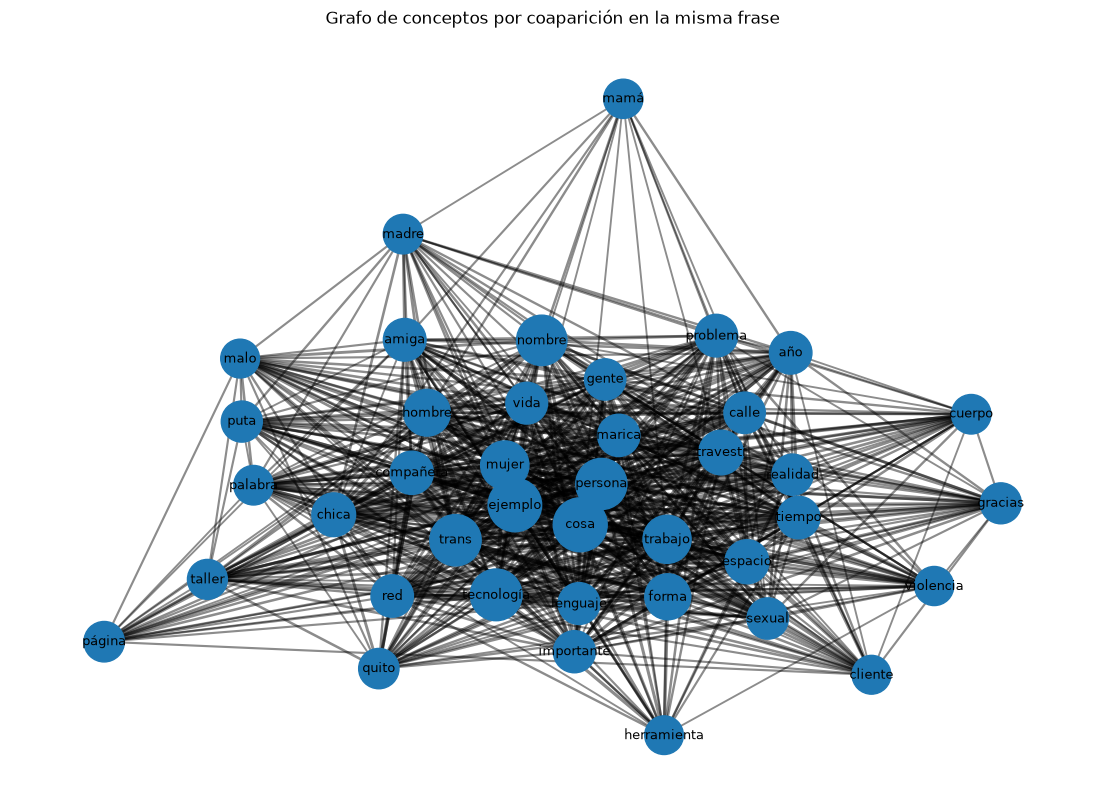

In [31]:

def draw_property_graph(
    graph,
    min_edge_weight=1,
    max_nodes=50,
    figsize=(14, 10),
    seed=42
):
    # Selección de los nodos más frecuentes
    ranked = sorted(
        graph.nodes,
        key=lambda n: graph.nodes[n].get("frequency", 0),
        reverse=True
    )[:max_nodes]

    sub = graph.subgraph(ranked).copy()

    # Filtrar aristas débiles
    remove_edges = [
        (u, v)
        for u, v, d in sub.edges(data=True)
        if d.get("weight", 1) < min_edge_weight
    ]
    sub.remove_edges_from(remove_edges)

    # Quitar aislados después del filtro
    sub.remove_nodes_from(list(nx.isolates(sub)))

    if not sub.nodes:
        print("No hay nodos/aristas con los filtros indicados.")
        return

    pos = nx.spring_layout(sub, seed=seed, weight="weight")
    sizes = [
        250 + 80 * (sub.nodes[n].get("frequency", 1) ** 0.5)
        for n in sub.nodes
    ]
    widths = [
        0.5 + 0.6 * (d.get("weight", 1) ** 0.5)
        for _, _, d in sub.edges(data=True)
    ]

    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(sub, pos, node_size=sizes)
    nx.draw_networkx_edges(sub, pos, width=widths, alpha=0.45)
    nx.draw_networkx_labels(sub, pos, font_size=9)
    plt.title("Grafo de conceptos por coaparición en la misma frase")
    plt.axis("off")
    plt.show()

# Ajusta según el corpus:
draw_property_graph(PG, min_edge_weight=2, max_nodes=40)


In [32]:
def draw_interactive_property_graph(min_edge_weight=1, max_nodes=50, concept_search=""):
    # Start with the full graph
    current_graph = PG.copy()

    # Filter nodes by search term (if provided)
    if concept_search:
        search_lower = concept_search.lower()
        nodes_to_keep = [
            n for n in current_graph.nodes
            if search_lower in n.lower()
        ]
        current_graph = current_graph.subgraph(nodes_to_keep).copy()

    # Select top nodes by frequency and filter edges based on weight
    if current_graph.nodes:
        # Rank nodes by frequency
        ranked_nodes = sorted(
            current_graph.nodes,
            key=lambda n: current_graph.nodes[n].get("frequency", 0),
            reverse=True
        )

        # Take only the top `max_nodes` after potential search filtering
        nodes_for_display = ranked_nodes[:max_nodes]
        display_graph = current_graph.subgraph(nodes_for_display).copy()

        # Filter edges based on min_edge_weight
        remove_edges = [
            (u, v)
            for u, v, d in display_graph.edges(data=True)
            if d.get("weight", 1) < min_edge_weight
        ]
        display_graph.remove_edges_from(remove_edges)

        # Remove isolated nodes after edge filtering
        display_graph.remove_nodes_from(list(nx.isolates(display_graph)))

        if not display_graph.nodes:
            print("No hay nodos/aristas con los filtros indicados.")
            return

        # Drawing logic (similar to draw_property_graph)
        plt.figure(figsize=(14, 10))
        pos = nx.spring_layout(display_graph, seed=42, weight="weight")
        sizes = [
            250 + 80 * (display_graph.nodes[n].get("frequency", 1) ** 0.5)
            for n in display_graph.nodes
        ]
        widths = [
            0.5 + 0.6 * (d.get("weight", 1) ** 0.5)
            for _, _, d in display_graph.edges(data=True)
        ]

        nx.draw_networkx_nodes(display_graph, pos, node_size=sizes)
        nx.draw_networkx_edges(display_graph, pos, width=widths, alpha=0.45)
        nx.draw_networkx_labels(display_graph, pos, font_size=9)
        plt.title(f"Grafo Interactivo de Conceptos (Peso min: {min_edge_weight}, Nodos max: {len(display_graph.nodes)})")
        plt.axis("off")
        plt.show()
    else:
        print("No hay nodos para mostrar después del filtrado.")


# Create interactive widgets
min_edge_weight_widget = widgets.IntSlider(
    value=PG.number_of_edges() > 0 and edges_df['weight'].min() or 1,
    min=1,
    max=PG.number_of_edges() > 0 and int(edges_df['weight'].max()) or 10,
    step=1,
    description="Peso mín. arista:",
    continuous_update=False
)

max_nodes_widget = widgets.IntSlider(
    value=min(50, PG.number_of_nodes()),
    min=5,
    max=PG.number_of_nodes(),
    step=5,
    description="Nodos máx.:",
    continuous_update=False
)

concept_search_widget = widgets.Text(
    value="",
    description="Buscar concepto:",
    placeholder="Escribe para filtrar conceptos",
    continuous_update=False
)

# Create an interactive output
interactive_plot = widgets.interactive_output(
    draw_interactive_property_graph,
    {
        'min_edge_weight': min_edge_weight_widget,
        'max_nodes': max_nodes_widget,
        'concept_search': concept_search_widget
    }
)

# Display the widgets and the interactive plot
display(widgets.VBox([
    widgets.HBox([min_edge_weight_widget, max_nodes_widget]),
    concept_search_widget,
    interactive_plot
]))

## 9. Exportación

In [33]:

# RDF/OWL para Protégé
ttl_path = OUTPUT_DIR / "corpus_conceptos_ecuador.ttl"
rdfxml_path = OUTPUT_DIR / "corpus_conceptos_ecuador.rdf"

g.serialize(destination=str(ttl_path), format="turtle")
g.serialize(destination=str(rdfxml_path), format="xml")

# Grafo de propiedades
graphml_path = OUTPUT_DIR / "conceptos_coocurrencia.graphml"
gexf_path = OUTPUT_DIR / "conceptos_coocurrencia.gexf"

nx.write_graphml(PG, graphml_path)
nx.write_gexf(PG, gexf_path)

# CSV
nodes_df = pd.DataFrame([
    {"concept": n, **data}
    for n, data in PG.nodes(data=True)
])

nodes_csv = OUTPUT_DIR / "property_graph_nodes.csv"
edges_csv = OUTPUT_DIR / "property_graph_edges.csv"
sentences_csv = OUTPUT_DIR / "sentences.csv"
occurrences_csv = OUTPUT_DIR / "occurrences.csv"

nodes_df.to_csv(nodes_csv, index=False)
edges_df.to_csv(edges_csv, index=False)
sentences_df.drop(columns=["concepts", "unique_concepts"]).to_csv(sentences_csv, index=False)
active_occ.to_csv(occurrences_csv, index=False)

print("Archivos generados:")
for p in [
    ttl_path, rdfxml_path, graphml_path, gexf_path,
    nodes_csv, edges_csv, sentences_csv, occurrences_csv
]:
    print(" -", p)


Archivos generados:
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/corpus_conceptos_ecuador.ttl
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/corpus_conceptos_ecuador.rdf
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/conceptos_coocurrencia.graphml
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/conceptos_coocurrencia.gexf
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/property_graph_nodes.csv
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/property_graph_edges.csv
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/sentences.csv
 - /content/drive/MyDrive/8-PROJEKT/FuRIA-Feminista-2025/fur-IA-vocabulario/data/salidas/occurrences.csv



## 10. Consulta SPARQL de ejemplo

Una vez abierto el `.ttl` en Protégé, puedes usar consultas SPARQL equivalentes en herramientas RDF que soporten consulta.

La siguiente consulta obtiene conceptos y frecuencias:


In [34]:

query = '''
PREFIX ex: <https://example.org/ecuador-corpus/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?concept ?label ?frequency
WHERE {
  ?concept a ex:Concept ;
           rdfs:label ?label ;
           ex:frequency ?frequency .
}
ORDER BY DESC(?frequency)
LIMIT 30
'''

for row in g.query(query):
    print(row)


(rdflib.term.URIRef('https://example.org/ecuador-corpus/concept/cosa'), rdflib.term.Literal('cosa', lang='es'), rdflib.term.Literal('247', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('https://example.org/ecuador-corpus/concept/ejemplo'), rdflib.term.Literal('ejemplo', lang='es'), rdflib.term.Literal('238', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('https://example.org/ecuador-corpus/concept/tecnolog%C3%ADa'), rdflib.term.Literal('tecnología', lang='es'), rdflib.term.Literal('202', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('https://example.org/ecuador-corpus/concept/trans'), rdflib.term.Literal('trans', lang='es'), rdflib.term.Literal('195', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('https://example.org/ecuador-corpus/concept/persona'), rdflib.term.Literal('persona', lang='es'), rdfli


## 11. Consulta por concepto y recuperación de frases

Esta función permite recuperar las frases donde aparece un concepto lematizado.


In [38]:

def sentences_for_concept(concept, max_rows=30):
    ids = occurrences_df.loc[
        occurrences_df["lemma"] == concept, "sentence_id"
    ].unique()

    return sentences_df[
        sentences_df["sentence_id"].isin(ids)
    ][["sentence_id", "file_name", "sentence"]].head(max_rows)

# Ejemplo:
display(sentences_for_concept("trans"))


,sentence_id,file_name,sentence
66,66,E45A 2.txt,Independientemente de que nosotras seamos muje...
124,124,E45A 2.txt,"Este es el de\nCuria Trans,\nque es la organiz..."
127,127,E45A 2.txt,"Este es\nel de\nCuria Trans,\nque es\nla organ..."
139,139,E45A 2.txt,Y actualmente\nlo que está\npasando\ncon las t...
141,141,E45A 2.txt,Por ejemplo\nsi nosotros\nbuscamos\nuna forma\...
152,152,E45A 2.txt,"Claro, todo lo que debe tener una mujer trans ..."
194,194,E45A 4.txt,El huracán\nAlgo que lleve como del aguagre\nO...
510,510,E45A 5.txt,a veces se pierden los abogados\nyo por ejempl...
613,613,E45A 5.txt,"Por ejemplo,\nyo en mis papeles\nen la ciudad\..."
1051,1051,E45A 5.txt,"Trans, representada en el mundial."



## 12. Extensión opcional: conceptos multi-palabra

El flujo anterior usa **lemas token a token**. Para un análisis semántico más rico conviene añadir conceptos multi-palabra, por ejemplo:

- `cambio climático`
- `violencia de género`
- `inteligencia artificial`
- nombres de organizaciones, territorios o comunidades.

Dos vías recomendadas:

1. añadir un `PhraseMatcher` de spaCy con un vocabulario controlado;
2. extraer `noun_chunks` o patrones sintácticos y normalizarlos.

Ejemplo con `PhraseMatcher`:


In [39]:

from spacy.matcher import PhraseMatcher

MULTIWORD_CONCEPTS = [
    # "cambio climático",
     "inteligencia artificial",
     "violencia de género",
]

phrase_matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
if MULTIWORD_CONCEPTS:
    phrase_matcher.add(
        "CONTROLLED_CONCEPT",
        [nlp.make_doc(x) for x in MULTIWORD_CONCEPTS]
    )

def find_multiword_concepts(text):
    doc = nlp(text)
    found = []
    for match_id, start, end in phrase_matcher(doc):
        span = doc[start:end]
        found.append({
            "text": span.text,
            "normalized": span.text.lower(),
            "start": span.start_char,
            "end": span.end_char,
        })
    return found

# Ejemplo:
# find_multiword_concepts("La inteligencia artificial puede analizar el cambio climático.")


In [40]:
# Ejemplo:
find_multiword_concepts("La inteligencia artificial puteril.")


[{'text': 'inteligencia artificial',
  'normalized': 'inteligencia artificial',
  'start': 3,
  'end': 26}]


## 13. Posible extensión hacia Neo4j

Los CSV `property_graph_nodes.csv` y `property_graph_edges.csv` ya contienen la estructura básica para un grafo de propiedades.

Una representación natural en Neo4j sería:

```cypher
(:Concept {name, frequency, sentence_frequency, document_frequency})
-[:CO_OCCURS_WITH {weight, sentence_ids, document_ids}]->
(:Concept)
```

Esto permite consultar comunidades, vecinos, caminos, centralidades y subgrafos temáticos.
